# 11 · Detecting pop-ins (refreshed classic)

A **pop-in** is a sudden displacement burst at nearly constant load — the
signature of dislocation nucleation or a small fracture event. Here we build a
**transparent, explainable** detector (no black box): a pop-in is where depth
jumps while load barely moves, i.e. a spike in **dh/dP** along the loading
curve. We validate it on a synthetic curve with a known pop-in, then apply it to
real data.

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
from scipy.ndimage import uniform_filter1d

def loading_segment(depth, load):
    k = int(np.argmax(load))                      # up to maximum load
    return depth[:k+1], load[:k+1]

def find_popins(depth, load, k_mad=6, min_load=0.2):
    """Flag indices where dh/dP is anomalously large (a displacement burst)."""
    h = uniform_filter1d(depth.astype(float), 3)
    P = uniform_filter1d(load.astype(float), 3)
    dP = np.gradient(P); dh = np.gradient(h)
    ratio = dh / np.where(np.abs(dP) < 1e-6, np.nan, dP)
    ratio[P < min_load] = np.nan                  # ignore noisy surface approach
    med = np.nanmedian(ratio); mad = np.nanmedian(np.abs(ratio - med)) + 1e-9
    score = (ratio - med) / (1.4826 * mad)        # robust z-score
    return np.where(score > k_mad)[0], score

## 1 · Validate on a synthetic curve
We build an elastic–plastic curve and inject a 12 nm burst at a known load — the detector must find it *there*.

detected near injected index: [ 11  12  13  14  15  16 178 179 180 181]  (true = 180 )


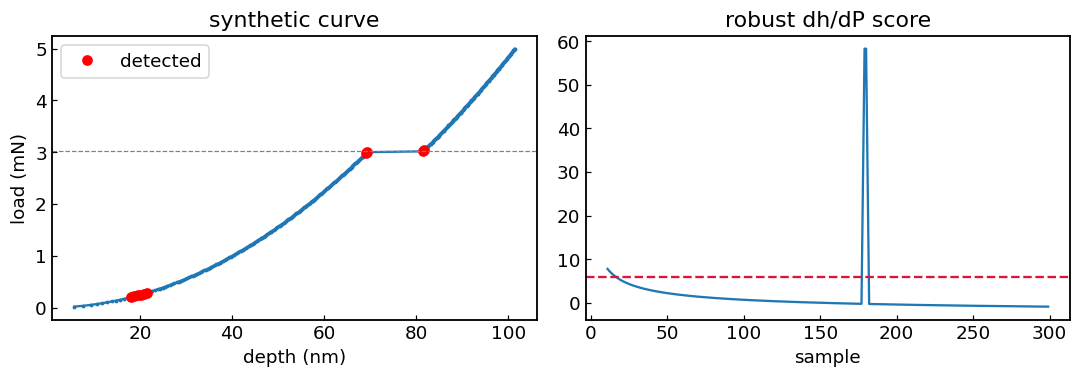

In [3]:
P = np.linspace(0.02, 5, 300)
h = 40*np.sqrt(P)                                   # smooth baseline
k_true = 180; h[k_true:] += 12.0                    # <-- injected pop-in
idx, score = find_popins(h, P)
fig, ax = plt.subplots(1,2, figsize=(10,3.6))
ax[0].plot(h, P, ".-", ms=3); ax[0].plot(h[idx], P[idx], "ro", label="detected")
ax[0].axhline(P[k_true], color="grey", ls="--", lw=.8); ax[0].set_xlabel("depth (nm)")
ax[0].set_ylabel("load (mN)"); ax[0].legend(); ax[0].set_title("synthetic curve")
ax[1].plot(score); ax[1].axhline(6, color="crimson", ls="--"); ax[1].set_title("robust dh/dP score")
ax[1].set_xlabel("sample"); fig.tight_layout()
print("detected near injected index:", idx, " (true =", k_true, ")")

## 2 · Apply to real load–depth curves
Run the same detector over real indents and mark any bursts on the loading branch.

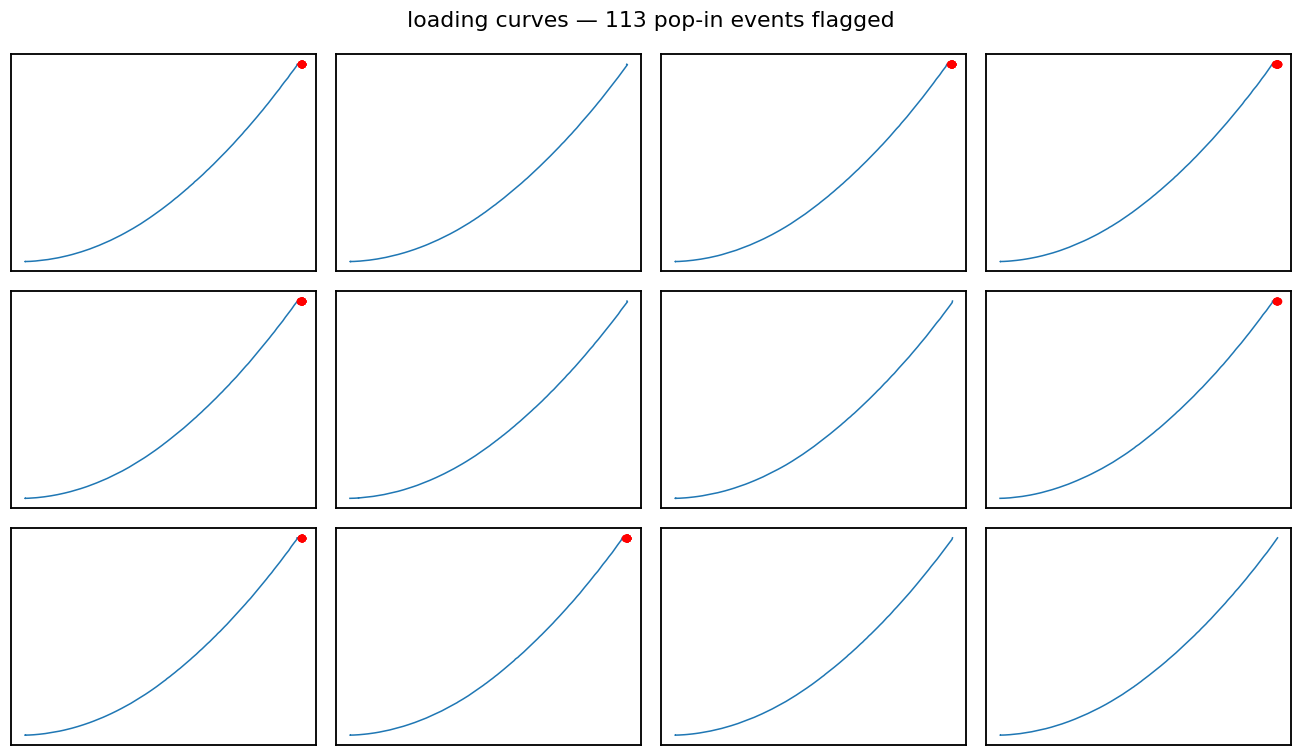

In [4]:
curves = mm.load_curves(12)
fig, ax = plt.subplots(3,4, figsize=(12,7))
n_found = 0
for a,(d,l) in zip(ax.ravel(), curves):
    h,P = loading_segment(d,l)
    idx,_ = find_popins(h,P)
    n_found += len(idx)
    a.plot(h,P,lw=1); a.plot(h[idx],P[idx],"ro",ms=4)
    a.set_xticks([]); a.set_yticks([])
fig.suptitle(f"loading curves — {n_found} pop-in events flagged"); fig.tight_layout()

## Recap
- A pop-in is a **dh/dP** anomaly; a **robust (MAD) threshold** finds it without
  training data and without a black box.
- Always **validate a detector on a known signal** before trusting it on real
  curves — here, a synthetic pop-in at a known load.
- These flags feed naturally into the autoencoder anomaly score (notebook 05)
  and into curve-level classification (notebook 04).